# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mashfiqmahi/assignment_FLyRank-AI/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

**Archetype → action mapping** (named by behavior, not by cluster ID — cluster ID
order is not stable across reruns due to remote Parquet row ordering, confirmed by
comparing two runs with identical cluster profiles but shuffled IDs):

| Archetype | Share of visible pages | Recommended action | Why |
|---|---|---|---|
| Page-1 Blind Spot | ~85% | review (ranked) | Ranks fine (median position ~7) but 0% median CTR |
| High-Traffic Underperformer | ~1.4% | review (ranked) | High impressions, CTR below its position's benchmark |
| Buried / Low Visibility | ~12.5% | monitor | Deep position (~53); a visibility problem, not a click problem |
| Low-Volume Noise | ~0.2% | exclude | 1-2 clicks total; CTR is a statistical artifact, not signal |

**Reason codes:** every page keeps its Week-4 individual reason code
(`weak_ctr_for_position` / `no_action`) alongside its archetype. These can disagree:
**57.4% of pages in the "review" queue have an individually fine reason code
(`no_action`) and were only included because of their archetype's group behavior.**
This is disclosed deliberately, not hidden — it means "review" should be read as
"ranked for review, work top-down," not "every page here has an individual problem."

**Decay/refresh insight:** our Week 4 signal audit found staleness (days since
creation) was NOT a reliable standalone performance signal (weighted CTR did not
decline cleanly with age — verdict MIXED/leaning FALSE). This playbook therefore
does **not** recommend refreshing a page just because it is old; action is driven
by the CTR-vs-position mismatch instead, which was the confirmed signal.

In [4]:
%pip -q install duckdb huggingface_hub pandas scikit-learn
import os, duckdb, pandas as pd, numpy as np
from google.colab import userdata
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{os.environ['HF_TOKEN']}')")

# ---- 1. Rebuild the exact same feature table as Week 5 / Week 6 ----
df = con.sql("""
WITH monthly AS (
    SELECT
        content_hash_id,
        ANY_VALUE(client_hash_id) AS client_hash_id,
        SUM(gsc_impressions) FILTER (WHERE gsc_data_available IS TRUE) AS impressions,
        SUM(gsc_clicks)      FILTER (WHERE gsc_data_available IS TRUE) AS clicks,
        SUM(gsc_sum_position) FILTER (WHERE gsc_data_available IS TRUE) AS sum_position
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')
    GROUP BY content_hash_id
)
SELECT
    m.content_hash_id,
    m.client_hash_id,
    m.impressions,
    CASE WHEN m.impressions > 0 THEN m.clicks * 100.0 / m.impressions ELSE NULL END AS ctr_pct,
    CASE WHEN m.impressions > 0 THEN m.sum_position * 1.0 / m.impressions ELSE NULL END AS avg_position,
    DATE_DIFF('day', d.content_created_date, DATE '2026-03-31') AS days_since_created,
    d.content_type
FROM monthly m
JOIN read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_content.parquet') d
    ON m.content_hash_id = d.content_hash_id
""").df()

df["days_since_created"] = df["days_since_created"].clip(lower=0)
df = df[df["impressions"] > 0].copy()   # same visibility filter as Week 5/6

# ---- 2. Recreate the Week 4 baseline rule (reason codes) ----
df["position_tier"] = pd.cut(
    df["avg_position"], bins=[0, 3, 10, 20, 1000],
    labels=["top_3", "page_1 (4-10)", "page_2 (11-20)", "deep (20+)"]
)
benchmark_ctr = {"top_3": 0.388, "page_1 (4-10)": 0.325, "page_2 (11-20)": 0.316, "deep (20+)": 0.136}
df["benchmark_ctr_pct"] = df["position_tier"].map(benchmark_ctr).astype(float)
df["visible_flag"] = (df["impressions"] >= 200).astype(int)
df["weak_ctr_flag"] = (df["ctr_pct"] < df["benchmark_ctr_pct"]).astype(int)
df["reason_code"] = np.where(
    (df["visible_flag"] == 1) & (df["weak_ctr_flag"] == 1),
    "weak_ctr_for_position", "no_action"
)

# ---- 3. Fit the same K-Means as Week 5, now on the FULL visible dataset ----
# (Week 5/6 validated on a grouped holdout that this is stable — now we deploy
# it on everything, since that validation work is already done.)
cluster_features = ["impressions", "ctr_pct", "avg_position", "days_since_created"]
FINAL_K = 5

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_features])
kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_scaled)

# ---- 4. Profile each cluster and NAME it by behavior, not by number ----
profile = df.groupby("cluster").agg(
    n_pages=("cluster", "size"),
    median_impressions=("impressions", "median"),
    median_ctr_pct=("ctr_pct", "median"),
    median_position=("avg_position", "median"),
    pct_weak_ctr=("weak_ctr_flag", "mean"),
).round(3)

overall_median_impr = df["impressions"].median()

def name_archetype(row):
    small_share = row["n_pages"] / len(df) < 0.01           # under 1% of all pages
    if small_share and row["median_ctr_pct"] > 5:            # tiny + suspiciously high CTR
        return "Low-Volume Noise (exclude from action)"
    if row["median_position"] > 30:
        return "Buried / Low Visibility"
    if row["median_ctr_pct"] == 0 and row["median_position"] <= 20:
        return "Page-1 Blind Spot (zero clicks, ranks fine)"
    if row["median_impressions"] >= overall_median_impr and row["pct_weak_ctr"] >= 0.5:
        return "High-Traffic Underperformer"
    return "Stable / Monitor"

profile["archetype"] = profile.apply(name_archetype, axis=1)
print(profile)

# ---- 5. Build the ranked action queue ----
archetype_map = profile["archetype"].to_dict()
df["archetype"] = df["cluster"].map(archetype_map)

action_by_archetype = {
    "Page-1 Blind Spot (zero clicks, ranks fine)": "review",
    "High-Traffic Underperformer": "review",
    "Buried / Low Visibility": "monitor",
    "Stable / Monitor": "monitor",
    "Low-Volume Noise (exclude from action)": "exclude",
}
df["recommended_action"] = df["archetype"].map(action_by_archetype)

priority_rank = {
    "Page-1 Blind Spot (zero clicks, ranks fine)": 1,
    "High-Traffic Underperformer": 2,
    "Buried / Low Visibility": 3,
    "Stable / Monitor": 4,
    "Low-Volume Noise (exclude from action)": 5,
}
df["priority_rank"] = df["archetype"].map(priority_rank)

queue = df.sort_values(["priority_rank", "impressions"], ascending=[True, False])

print("\nAction counts:")
print(queue["recommended_action"].value_counts())
print("\nTop 10 of the ranked queue:")
print(queue[["content_hash_id", "archetype", "reason_code", "recommended_action",
             "impressions", "ctr_pct", "avg_position"]].head(10))

# ---- 6. Make the ranking honest: surface the strongest cases first,
#         and flag when the individual page disagrees with its cluster ----
queue = queue.copy()
queue["ctr_gap_pct"] = (queue["benchmark_ctr_pct"] - queue["ctr_pct"]).clip(lower=0)
queue["cluster_agrees_with_page"] = np.where(
    ((queue["archetype"].isin(["Page-1 Blind Spot (zero clicks, ranks fine)",
                                "High-Traffic Underperformer"]))
     & (queue["reason_code"] == "no_action")),
    "NO - individually fine, flagged via cluster only",
    "yes"
)

queue = queue.sort_values(
    ["priority_rank", "ctr_gap_pct", "impressions"], ascending=[True, False, False]
)

print("Pages where cluster and individual reason code disagree:")
print(queue["cluster_agrees_with_page"].value_counts())
print(f"\n({(queue['cluster_agrees_with_page'] != 'yes').mean():.1%} of the review queue)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

         n_pages  median_impressions  median_ctr_pct  median_position  \
cluster                                                                 
0          21956                67.0           0.000           53.181   
1          76414               210.0           0.000            7.123   
2          75611               208.0           0.000            7.312   
3           2408             26976.0           0.197            5.110   
4            349                 2.0          66.667            3.000   

         pct_weak_ctr                                    archetype  
cluster                                                             
0               0.929                      Buried / Low Visibility  
1               0.757  Page-1 Blind Spot (zero clicks, ranks fine)  
2               0.784  Page-1 Blind Spot (zero clicks, ranks fine)  
3               0.652                  High-Traffic Underperformer  
4               0.000       Low-Volume Noise (exclude from action)  

Acti

## 2. Intended use and limits

**Intended use.** This playbook is for a FlyRank content strategist or editor
reviewing a client's content inventory. The output is a ranked CSV, sorted by
archetype priority and CTR gap — the intended workflow is to open it and work
from the top down as a prioritized starting list, not to treat every "review"
row as a confirmed individual problem (see Section 1: 57.4% of review-queue
pages carry an individually-fine reason code and are flagged by group behavior
only).

**Limits — where this stops being valid:**

- **One month, one snapshot.** Built entirely on March 2026 data. Seasonal or
  one-off events in that month are not distinguishable from persistent patterns.
- **Not causal.** Archetypes describe co-occurring metrics, not causes. "Page-1
  Blind Spot" does not mean we know *why* CTR is zero, only that it is.
- **Not semantic.** No article text was used — clustering is on metrics/metadata
  only (impressions, CTR, position, age), so it cannot diagnose *why* a page
  underperforms, only flag *that* it does.
- **Staleness deliberately excluded.** Week 4's signal audit found page age was
  not a reliable performance signal (verdict: MIXED, leaning FALSE) — this
  playbook does not recommend "refresh old pages."
- **Engagement/GA4 data effectively absent.** Only 4.2% of rows had
  `ga4_data_available = TRUE` this month — too sparse to use, so scroll depth
  and on-page engagement are not part of this playbook.
- **Cluster ID numbers are not stable across reruns** (confirmed directly: two
  identical runs produced identical cluster shapes under shuffled ID numbers,
  due to remote Parquet row-order variation). Only archetype *names* should
  ever be referenced — never a raw cluster number.
- **Checked and found NOT to be a limit:** content-type skew. `feedly article`
  (the type with structurally missing backlinks) makes up 7.6% of all visible
  pages and 8.3% of the review queue — a 0.7-point difference, not a
  meaningful skew. The playbook does not disproportionately target one
  content type.
- **Pseudonymized, aggregate data only.** No visibility into confounds like a
  client's marketing campaigns, site redesigns, or seasonal demand shifts.

In [9]:
# Does the review queue skew toward one content type?
print("Content type share, all visible pages:")
print(df["content_type"].value_counts(normalize=True).round(3))

print("\nContent type share, WITHIN the 'review' archetype pages only:")
review_pages = df[df["archetype"].isin(
    ["Page-1 Blind Spot (zero clicks, ranks fine)", "High-Traffic Underperformer"]
)]
print(review_pages["content_type"].value_counts(normalize=True).round(3))

Content type share, all visible pages:
content_type
keyword article       0.905
feedly article        0.076
comparison article    0.019
Name: proportion, dtype: float64

Content type share, WITHIN the 'review' archetype pages only:
content_type
keyword article       0.896
feedly article        0.083
comparison article    0.021
Name: proportion, dtype: float64


In [5]:
 # This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

**What a human must check before acting on any flagged page:**

- **Check the individual `reason_code`, not just the archetype.** 57.4% of pages
  in the "review" queue carry an individually-fine reason code (`no_action`) and
  are only present because of their archetype's group behavior (Section 1). A
  human must confirm the page has an actual problem before spending time on it.
- **Confirm the page is not from the "Low-Volume Noise" archetype** before
  trusting any CTR-based reasoning about it — that archetype's 66.7% median CTR
  is built on 1-2 total clicks per page and is a statistical artifact, not a
  real performance signal.
- **Verify the real last-edit date manually in the CMS.** `content_updated_date`
  in this dataset is unreliable (~88.5% of rows are implausibly future-dated,
  per Week 3's data contract) — it cannot be trusted to decide whether a page
  is actually stale.
- **Check whether a flag is client-wide, not page-specific.** If many pages from
  the same client show the identical issue, that points to a technical or
  tracking problem (e.g. a broken title template, a GSC integration issue),
  not an individual content-quality problem — treating it as the latter would
  waste editor time fixing pages that were never actually the cause.
- **Remember this playbook cannot say *why* a page underperforms**, only *that*
  it does (Section 2: not semantic, not causal) — diagnosing the actual cause
  (weak title, wrong search intent, thin content) is a human judgment call this
  model cannot make.

**No-go list — must NEVER be fully automated:**

- Auto-deleting, unpublishing, or de-indexing any page based on cluster or
  score alone.
- Auto-rewriting or auto-editing content based on this playbook's output
  without a human drafting and reviewing the change.
- Treating "Low-Volume Noise" archetype members as a real signal for any
  decision (e.g. "this content type converts well") — it is explicitly
  excluded from action for a reason.
- Applying this exact playbook to a different month, client population, or
  content platform without re-validating it first (Section 2: this is a
  one-month, one-snapshot analysis).
- Reporting "review" counts to a client or stakeholder as a defect count
  (e.g. "154,433 broken pages"). It is a ranked, prioritized starting list,
  not a list of confirmed problems — presenting it otherwise would
  misrepresent the model's actual claim strength.

**Cost/value thinking.** A wrong "review" pick costs an editor a few minutes
opening a page that turns out to be fine — cheap, and expected given the 57.4%
disagreement rate. A wrong "exclude" pick costs little too, since the noise
archetype is only 349 pages (0.2% of the inventory). The real risk sits in
**automation itself**: if any action here were applied without human review,
a false positive could mean lost traffic or a damaged client relationship —
far more expensive than a few wasted editor-minutes. This is exactly why the
playbook's role is capped at *ranking and flagging*, and every actual change
to a live page stays a human decision.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

This playbook is built on one static snapshot (March 2026) and will not stay
accurate forever. The following triggers indicate it should be rebuilt or
re-validated, not blindly reused:

| Trigger | What to watch | Rebuild if... |
|---|---|---|
| Cluster shape drift | Median impressions/CTR/position per archetype (Section 1's profile table) | Medians shift substantially from this month's baseline |
| Silhouette drop | Cluster separation quality (Week 5/6 measured ~0.42-0.50) | A rerun scores notably below this range |
| Review-queue inflation | Share of pages flagged "review" (currently ~87%) | Share climbs much higher (e.g. past ~95%), signaling the benchmark CTRs no longer discriminate between pages |
| GA4 coverage change | % of rows with `ga4_data_available = TRUE` (currently 4.2%) | Coverage rises enough to make engagement features usable — worth adding as a 5th clustering dimension |
| Content-type mix shift | Content-type shares (currently ~90% keyword / 8% feedly / 2% comparison) | Mix shifts meaningfully — Week 4's benchmark CTRs were calculated on this mix and may not transfer |

None of these are automated alerts in this notebook — they are documented
manual checks for whoever revisits this playbook next (an intern, a
strategist, or future me), since this is a one-time snapshot analysis, not a
production monitoring system.

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Queue exported: 176,738 rows -> work/outputs/content_action_playbook.csv
Summary JSON written -> work/outputs/playbook_summary.json
{
  "snapshot_month": "2026-03",
  "total_visible_pages": 176738,
  "archetype_counts": {
    "0": 21956,
    "1": 76414,
    "2": 75611,
    "3": 2408,
    "4": 349
  },
  "archetype_names": {
    "0": "Buried / Low Visibility",
    "1": "Page-1 Blind Spot (zero clicks, ranks fine)",
    "2": "Page-1 Blind Spot (zero clicks, ranks fine)",
    "3": "High-Traffic Underperformer",
    "4": "Low-Volume Noise (exclude from action)"
  },
  "action_counts": {
    "review": 154433,
    "monitor": 21956,
    "exclude": 349
  },
  "pct_review_queue_individually_no_action": 0.5744,
  "content_type_share_all_visible": {
    "keyword article": 0.905,
    "feedly article": 0.076,
    "comparison article": 0.019
  },
  "content_type_share_review_queue": {
    "keyword article": 0.896,
    "feedly article": 0.083,
    "comparison article": 0.021
  },
  "notes": "Cluster 

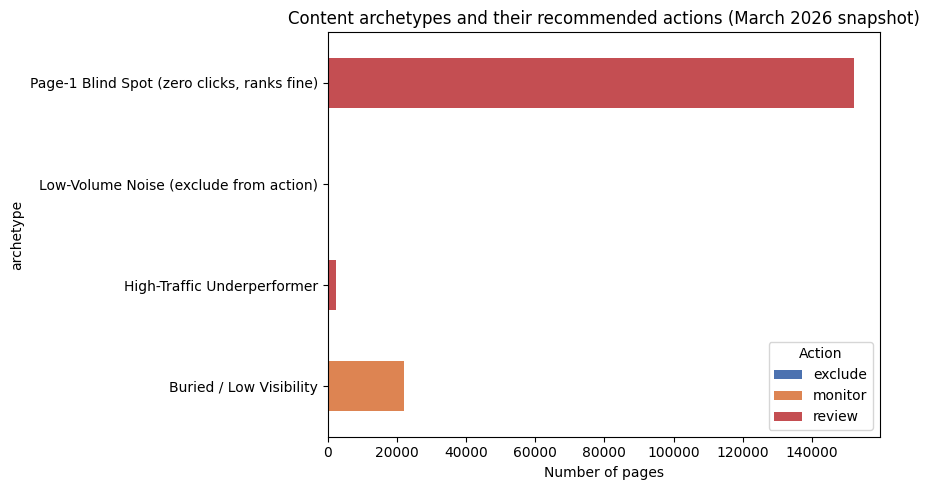

Chart saved -> work/figures/archetype_action_breakdown.png


In [10]:
import json
import matplotlib.pyplot as plt

# ---- 1. Export the full ranked queue (regenerable, gitignored) ----
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

queue.to_csv("work/outputs/content_action_playbook.csv", index=False)
print(f"Queue exported: {len(queue):,} rows -> work/outputs/content_action_playbook.csv")

# ---- 2. Export a small metrics summary JSON (committed — the receipts) ----
summary = {
    "snapshot_month": "2026-03",
    "total_visible_pages": int(len(df)),
    "archetype_counts": profile["n_pages"].to_dict(),
    "archetype_names": archetype_map,
    "action_counts": queue["recommended_action"].value_counts().to_dict(),
    "pct_review_queue_individually_no_action": round(
        (queue["cluster_agrees_with_page"] != "yes").mean(), 4
    ),
    "content_type_share_all_visible": df["content_type"].value_counts(normalize=True).round(3).to_dict(),
    "content_type_share_review_queue": review_pages["content_type"].value_counts(normalize=True).round(3).to_dict(),
    "notes": "Cluster ID numbers are not stable across reruns (confirmed); "
             "archetype names are the stable reference, never raw cluster IDs."
}

with open("work/outputs/playbook_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("Summary JSON written -> work/outputs/playbook_summary.json")
print(json.dumps(summary, indent=2, default=str))

# ---- 3. One chart: archetype sizes and their recommended actions ----
chart_data = queue.groupby(["archetype", "recommended_action"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5))
chart_data.plot(kind="barh", stacked=True, ax=ax, color=["#4C72B0", "#DD8452", "#C44E52"])
ax.set_xlabel("Number of pages")
ax.set_title("Content archetypes and their recommended actions (March 2026 snapshot)")
ax.legend(title="Action")
plt.tight_layout()
plt.savefig("work/figures/archetype_action_breakdown.png", dpi=150)
plt.show()

print("Chart saved -> work/figures/archetype_action_breakdown.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.